In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from scipy.stats import chi2_contingency

In [168]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
df = pd.read_csv('h1n1_vaccine_prediction.csv')
df.head()

,unique_id,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,...,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children,h1n1_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,White,Male,Below Poverty,Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",2.0,0.0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Principle City",0.0,0.0,0
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,0.0,0


In [7]:
df.shape

(26707, 34)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   unique_id                  26707 non-null  int64  
 1   h1n1_worry                 26615 non-null  float64
 2   h1n1_awareness             26591 non-null  float64
 3   antiviral_medication       26636 non-null  float64
 4   contact_avoidance          26499 non-null  float64
 5   bought_face_mask           26688 non-null  float64
 6   wash_hands_frequently      26665 non-null  float64
 7   avoid_large_gatherings     26620 non-null  float64
 8   reduced_outside_home_cont  26625 non-null  float64
 9   avoid_touch_face           26579 non-null  float64
 10  dr_recc_h1n1_vacc          24547 non-null  float64
 11  dr_recc_seasonal_vacc      24547 non-null  float64
 12  chronic_medic_condition    25736 non-null  float64
 13  cont_child_undr_6_mnths    25887 non-null  flo

In [9]:
df.describe()

,unique_id,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,...,has_health_insur,is_h1n1_vacc_effective,is_h1n1_risky,sick_from_h1n1_vacc,is_seas_vacc_effective,is_seas_risky,sick_from_seas_vacc,no_of_adults,no_of_children,h1n1_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,14433.00000,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,0.87972,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,0.32530,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,1.00000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,1.00000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,1.00000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


In [10]:
uniqueness = df.nunique(dropna=False).sort_values(ascending=False)
print(uniqueness)

unique_id                    26707
is_h1n1_risky                    6
sick_from_seas_vacc              6
is_h1n1_vacc_effective           6
is_seas_vacc_effective           6
sick_from_h1n1_vacc              6
is_seas_risky                    6
h1n1_worry                       5
qualification                    5
age_bracket                      5
no_of_children                   5
no_of_adults                     5
h1n1_awareness                   4
income_level                     4
race                             4
employment                       4
wash_hands_frequently            3
antiviral_medication             3
is_health_worker                 3
has_health_insur                 3
chronic_medic_condition          3
cont_child_undr_6_mnths          3
dr_recc_seasonal_vacc            3
dr_recc_h1n1_vacc                3
reduced_outside_home_cont        3
avoid_touch_face                 3
bought_face_mask                 3
contact_avoidance                3
avoid_large_gatherin

In [11]:
n_rows = len(df)
unique_cols = [c for c in df.columns if df[c].nunique(dropna=False) == n_rows]
print(unique_cols)
near_unique_cols = [c for c in df.columns if df[c].nunique(dropna=False) > 0.95 * n_rows ]
print(near_unique_cols)

['unique_id']
['unique_id']


In [12]:
df=df.drop(columns=['unique_id'])
df

,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,dr_recc_h1n1_vacc,...,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children,h1n1_vaccine
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,White,Male,Below Poverty,Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",2.0,0.0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Principle City",0.0,0.0,0
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0,0
26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,0
26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,White,Female,NaN,Not Married,Own,NaN,"MSA, Not Principle City",0.0,0.0,0
26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,...,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,Non-MSA,1.0,0.0,0


In [13]:
threshold = 0.75 * len(df)
cols_with_majority_same = [col for col in df.columns if df[col].value_counts(dropna=False).max() >= threshold]
print("\
Columns with 75%+ same values:")
print(cols_with_majority_same)

Columns with 75%+ same values:
['antiviral_medication', 'bought_face_mask', 'wash_hands_frequently', 'cont_child_undr_6_mnths', 'is_health_worker', 'race', 'h1n1_vaccine']


In [14]:
# Find duplicate rows
duplicates = df[df.duplicated()]

# Count of duplicates
print(f"Total duplicates: {duplicates.shape[0]}")

Total duplicates: 4


In [15]:
r=df.drop_duplicates()

In [16]:
print(pd.crosstab(df['is_health_worker'], df['h1n1_vaccine'], normalize='index'))

h1n1_vaccine             0         1
is_health_worker                    
0.0               0.811207  0.188793
1.0               0.590548  0.409452


In [17]:
df.isna().sum().sort_values(ascending=False)

has_health_insur             12274
income_level                  4423
dr_recc_seasonal_vacc         2160
dr_recc_h1n1_vacc             2160
housing_status                2042
employment                    1463
marital_status                1408
qualification                 1407
chronic_medic_condition        971
cont_child_undr_6_mnths        820
is_health_worker               804
sick_from_seas_vacc            537
is_seas_risky                  514
is_seas_vacc_effective         462
sick_from_h1n1_vacc            395
is_h1n1_vacc_effective         391
is_h1n1_risky                  388
no_of_children                 249
no_of_adults                   249
contact_avoidance              208
avoid_touch_face               128
h1n1_awareness                 116
h1n1_worry                      92
avoid_large_gatherings          87
reduced_outside_home_cont       82
antiviral_medication            71
wash_hands_frequently           42
bought_face_mask                19
age_bracket         

In [18]:
def imputnull(df):
    for col in df.columns:
        if col in df.select_dtypes(include=['number']).columns:
            if df[col].isna().any() and df[col].skew()<3:
                df[col]=df[col].fillna(df[col].mean())
            else:
                df[col]=df[col].fillna(df[col].median())
        else:
            if df[col].isna().any():
                df[col]=df[col].fillna(df[col].mode()[0])

imputnull(df)

In [19]:
for i in df.select_dtypes(include='number').columns:
    print(f"{i} : skewness = {df[i].skew()}")

h1n1_worry : skewness = -0.1601894349905861
h1n1_awareness : skewness = -0.23974529593478325
antiviral_medication : skewness = 4.192998759321439
contact_avoidance : skewness = -1.0152670791427758
bought_face_mask : skewness = 3.4032525076655538
wash_hands_frequently : skewness = -1.7177308626642775
avoid_large_gatherings : skewness = 0.5904848417931499
reduced_outside_home_cont : skewness = 0.6892861939327014
avoid_touch_face : skewness = -0.7601783244727764
dr_recc_h1n1_vacc : skewness = 1.4078680058830322
dr_recc_seasonal_vacc : skewness = 0.7555929750087342
chronic_medic_condition : skewness = 0.9800766937497095
cont_child_undr_6_mnths : skewness = 3.0951053646303706
is_health_worker : skewness = 2.5000011242293927
has_health_insur : skewness = -3.1760212400853107
is_h1n1_vacc_effective : skewness = -0.909386366882013
is_h1n1_risky : skewness = 0.677898278720701
sick_from_h1n1_vacc : skewness = 0.6561503481199442
is_seas_vacc_effective : skewness = -1.3267005107817156
is_seas_risky 

In [20]:
df.columns

Index(['h1n1_worry', 'h1n1_awareness', 'antiviral_medication',
       'contact_avoidance', 'bought_face_mask', 'wash_hands_frequently',
       'avoid_large_gatherings', 'reduced_outside_home_cont',
       'avoid_touch_face', 'dr_recc_h1n1_vacc', 'dr_recc_seasonal_vacc',
       'chronic_medic_condition', 'cont_child_undr_6_mnths',
       'is_health_worker', 'has_health_insur', 'is_h1n1_vacc_effective',
       'is_h1n1_risky', 'sick_from_h1n1_vacc', 'is_seas_vacc_effective',
       'is_seas_risky', 'sick_from_seas_vacc', 'age_bracket', 'qualification',
       'race', 'sex', 'income_level', 'marital_status', 'housing_status',
       'employment', 'census_msa', 'no_of_adults', 'no_of_children',
       'h1n1_vaccine'],
      dtype='object')

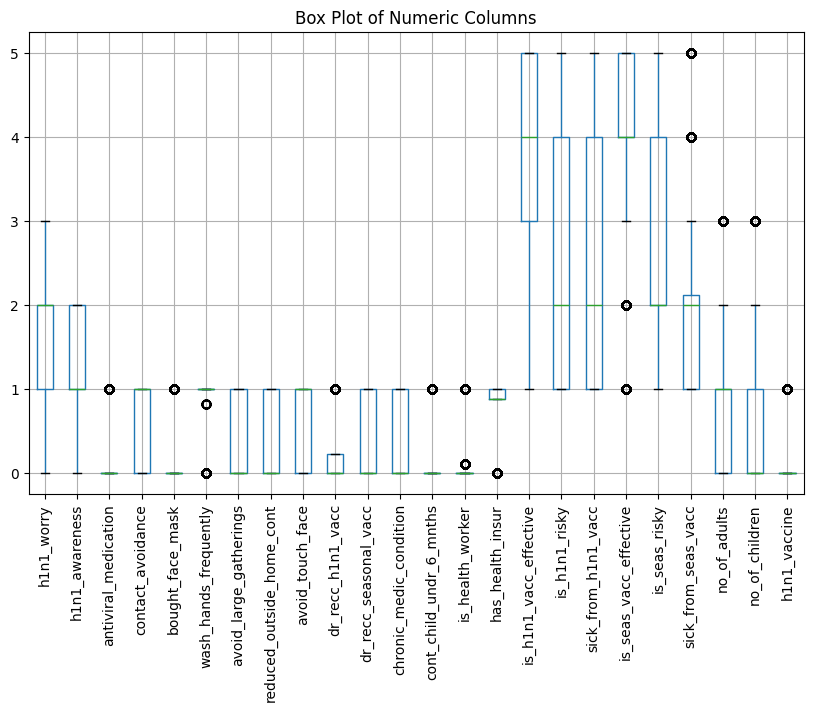

In [21]:
numeric_cols = df.select_dtypes(include=['float64', 'int64','int32']).columns
# Plot box plots for each numeric column
plt.figure(figsize=(10, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Box Plot of Numeric Columns')
plt.show()

In [24]:
le = LabelEncoder()
cols=['h1n1_worry', 'h1n1_awareness', 'antiviral_medication',
       'contact_avoidance', 'bought_face_mask', 'wash_hands_frequently',
       'avoid_large_gatherings', 'reduced_outside_home_cont',
       'avoid_touch_face', 'dr_recc_h1n1_vacc', 'dr_recc_seasonal_vacc',
       'chronic_medic_condition', 'cont_child_undr_6_mnths',
       'is_health_worker', 'has_health_insur', 'is_h1n1_vacc_effective',
       'is_h1n1_risky', 'sick_from_h1n1_vacc', 'is_seas_vacc_effective',
       'is_seas_risky', 'sick_from_seas_vacc', 'age_bracket', 'qualification',
       'race', 'sex', 'income_level', 'marital_status', 'housing_status',
       'employment', 'census_msa', 'no_of_adults', 'no_of_children',
       'h1n1_vaccine']
for col in cols:
    df[col] = le.fit_transform(df[col])
print(df)

       h1n1_worry  h1n1_awareness  antiviral_medication  contact_avoidance  \
0               1               0                     0                  0   
1               4               3                     0                  2   
2               1               1                     0                  2   
3               1               1                     0                  2   
4               3               1                     0                  2   
...           ...             ...                   ...                ...   
26702           3               0                     0                  2   
26703           1               3                     0                  2   
26704           3               3                     0                  2   
26705           1               1                     0                  0   
26706           0               0                     0                  2   

       bought_face_mask  wash_hands_frequently  avoid_large_gat

In [116]:
df

,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,dr_recc_h1n1_vacc,...,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children,h1n1_vaccine
0,1,0,0,0,0,0,0,1,1,0,...,3,0,2,1,0,1,2,0,0,0
1,3,2,0,1,0,1,0,1,1,0,...,3,1,2,1,1,0,0,0,0,0
2,1,1,0,1,0,0,0,0,0,2,...,3,1,0,1,0,0,0,2,0,0
3,1,1,0,1,0,1,1,0,0,0,...,3,0,2,1,1,1,1,0,0,0
4,2,1,0,1,0,1,1,0,1,0,...,3,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,2,0,0,1,0,0,0,1,0,0,...,3,0,0,1,0,1,2,0,0,0
26703,1,2,0,1,0,1,0,0,0,1,...,3,1,0,1,1,0,1,1,0,0
26704,2,2,0,1,1,1,1,0,1,0,...,3,0,3,1,0,3,0,0,0,0
26705,1,1,0,0,0,0,0,0,2,0,...,1,0,0,0,1,0,2,1,0,0


In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = df.columns
vif_df["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

print(vif_df)

                      Feature       VIF
0                  h1n1_worry  5.184714
1              h1n1_awareness  3.669253
2        antiviral_medication  1.115813
3           contact_avoidance  4.563771
4            bought_face_mask  1.165626
5       wash_hands_frequently  7.171279
6      avoid_large_gatherings  2.513576
7   reduced_outside_home_cont  2.442108
8            avoid_touch_face  4.055670
9           dr_recc_h1n1_vacc  2.430019
10      dr_recc_seasonal_vacc  2.671482
11    chronic_medic_condition  1.595503
12    cont_child_undr_6_mnths  1.117699
13           is_health_worker  1.296085
14           has_health_insur  6.384386
15     is_h1n1_vacc_effective  9.666752
16              is_h1n1_risky  3.337648
17        sick_from_h1n1_vacc  2.780127
18     is_seas_vacc_effective  8.988008
19              is_seas_risky  3.917852
20        sick_from_seas_vacc  2.180446
21                age_bracket  4.952476
22              qualification  3.615161
23                       race  8.126633


In [89]:
# Define X, y
y = df['h1n1_vaccine']
X = df.drop(columns=['h1n1_vaccine'])

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [91]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.87383117, -1.52252561, -0.22629268, ...,  1.4168754 ,
        -1.37743575, -0.61779355],
       [ 1.33343347,  1.29529506, -0.22629268, ..., -1.01237871,
        -1.37743575, -0.61779355],
       [-0.87383117, -0.58325206, -0.22629268, ..., -1.01237871,
         1.24360471, -0.61779355],
       ...,
       [ 0.59767859,  1.29529506, -0.22629268, ..., -1.01237871,
        -1.37743575, -0.61779355],
       [-0.87383117, -0.58325206, -0.22629268, ...,  1.4168754 ,
         0.36992456, -0.61779355],
       [-1.60958605, -1.52252561, -0.22629268, ...,  0.20224834,
         0.36992456, -0.61779355]])

In [92]:
X_train.shape

(18694, 32)

In [93]:
X_test.shape

(8013, 32)

In [94]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [95]:
# Baseline logistic regression model
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [96]:
y_pred_proba = logreg.predict_proba(X_test)[:,1]
y_pred_proba

array([0.06960204, 0.13608527, 0.08182815, ..., 0.00331964, 0.00433678,
       0.02635692])

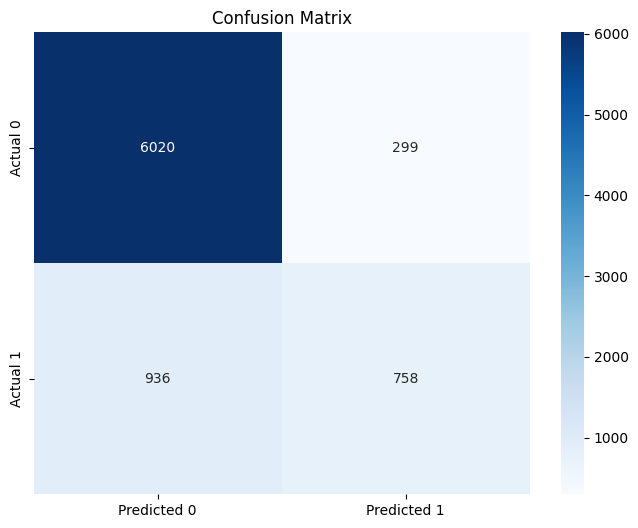

In [97]:
# 10.3 Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix')
plt.show()

In [126]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_pred1)
print(auc)

0.7675216495369281


In [127]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall   :", recall_score(y_test, y_pred1))
print("F1 Score :", f1_score(y_test, y_pred1))

Accuracy : 0.7873455634593786
Precision: 0.49799518845228546
Recall   : 0.7331759149940968
F1 Score : 0.5931232091690545


In [117]:
y_pred1

array([0, 0, 0, ..., 0, 0, 0])

In [125]:
from sklearn.linear_model import LogisticRegression

lasso_logit = LogisticRegression(
    penalty='elasticnet',          # LASSO
    solver='saga',
    l1_ratio=0.5,
    class_weight='balanced',
    max_iter=1000,
    C=1.0                  # inverse of regularization strength
)

lasso_logit.fit(X_train, y_train)
y_pred1 = lasso_logit.predict(X_test)              
y_prob1 = lasso_logit.predict_proba(X_test)[:, 1]

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64

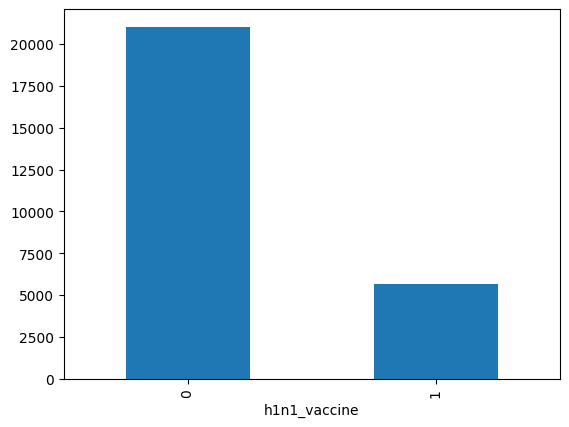

In [41]:
y.value_counts().plot(kind='bar')
y.value_counts()

In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42,sampling_strategy=1)
X_resampled, y_resampled = smote.fit_resample(X, y)

D:\Imarticus\Anaconda\envs\Deep_Learning\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


h1n1_vaccine
0    21033
1    21033
Name: count, dtype: int64

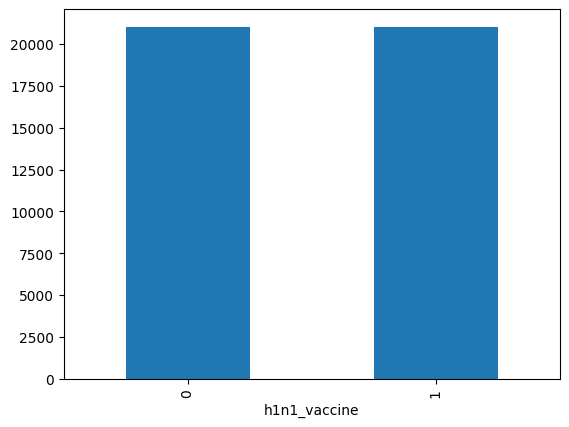

In [44]:
y_resampled.value_counts().plot(kind='bar')
y_resampled.value_counts()